# Data Preprocessing-Before Building Machine Learning Model

In [ ]:
# Steps of preprocessing data
# step 1: import necessary libraries
# step 2: read dataset
# step 3: sanity check of data
# step 4: Exploratory Data Analysis (EDA)
# step 5: handling missing values
# step 6: outlier treatments
# step 7: duplicates and garbage value treatments
# step 8: encoding of data

Step 1: import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: read dataset

In [5]:
df=pd.read_csv("C:/Users/DISCOVERY/Machine_Learning/Datasets/expenses.csv")

In [6]:
#head
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
#tail
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


Step 3: sanity check of data


In [8]:
#shape
df.shape

(1338, 7)

In [9]:
#info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
#finding missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
#finding duplicates
df.duplicated().sum()

np.int64(1)

In [17]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [19]:
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("***"*10)

sex
male      676
female    662
Name: count, dtype: int64
******************************
smoker
no     1064
yes     274
Name: count, dtype: int64
******************************
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
******************************


Step 4: Exploratory Data Analysis(EDA)

In [20]:
#descriptive statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [21]:
df.describe(include="object")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


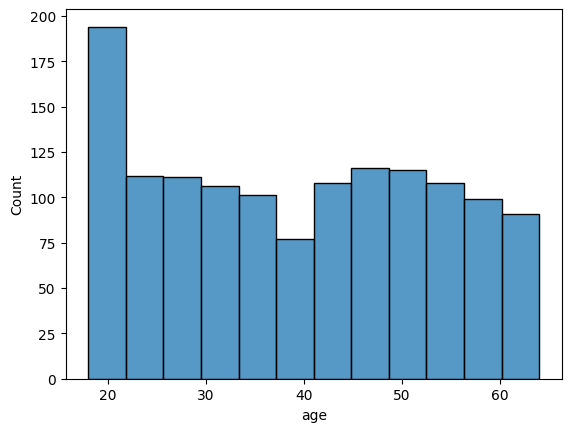

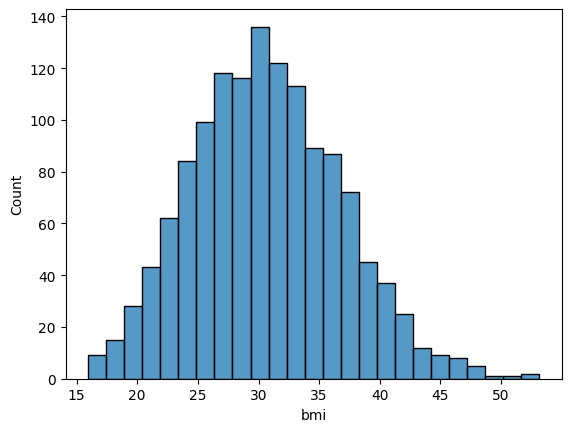

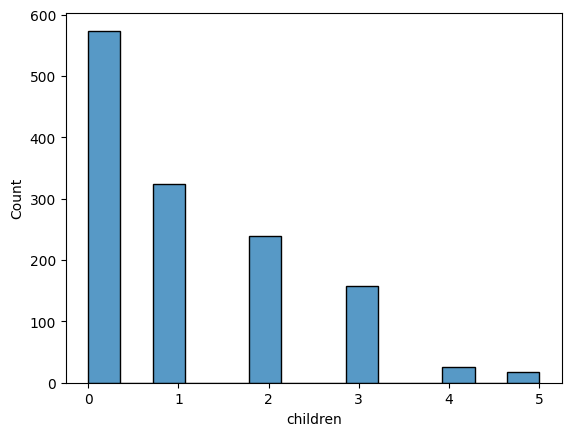

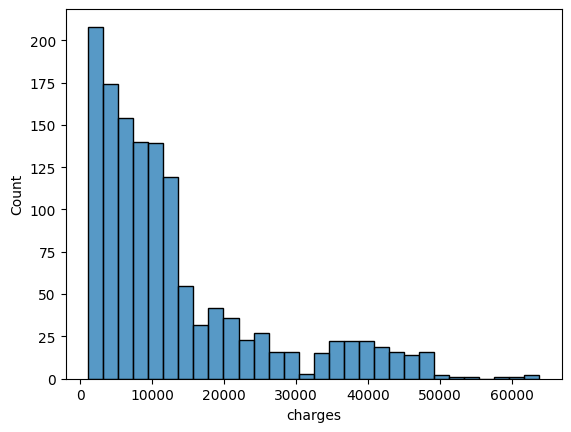

In [22]:
#histogram to understand the distribution
for i in df.select_dtypes(include="number").columns:
    sns.histplot(data=df,x=i)
    plt.show()

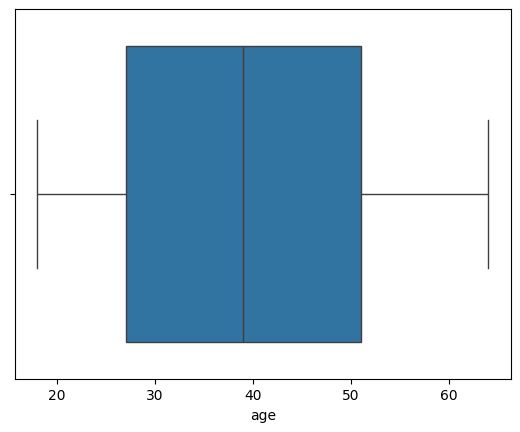

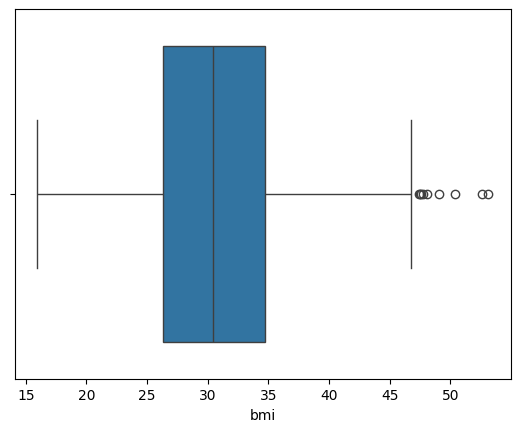

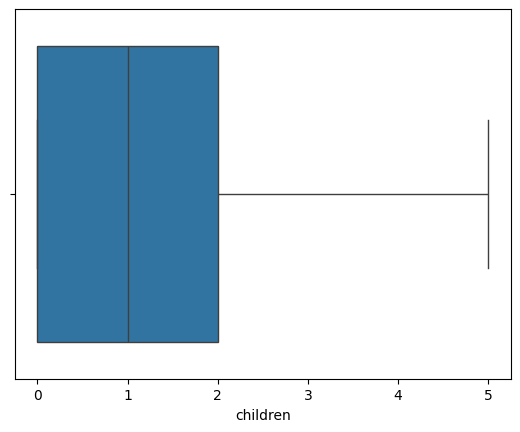

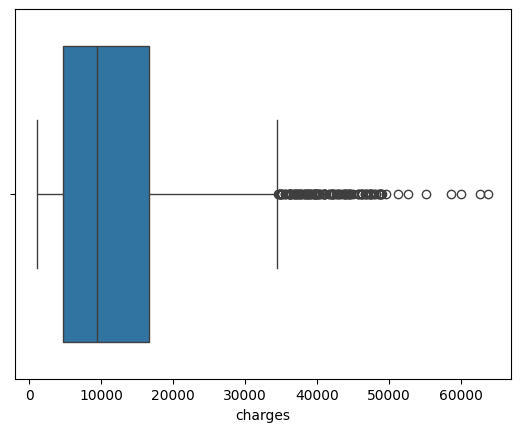

In [23]:
#boxplot-to-identify outliers
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show()

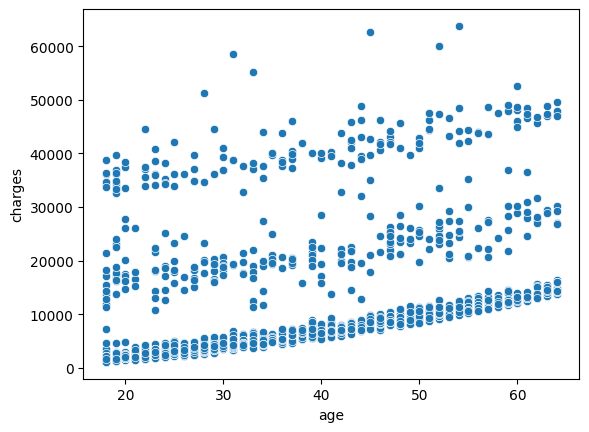

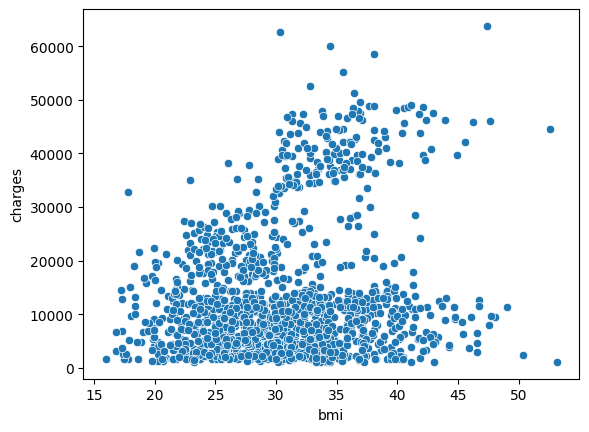

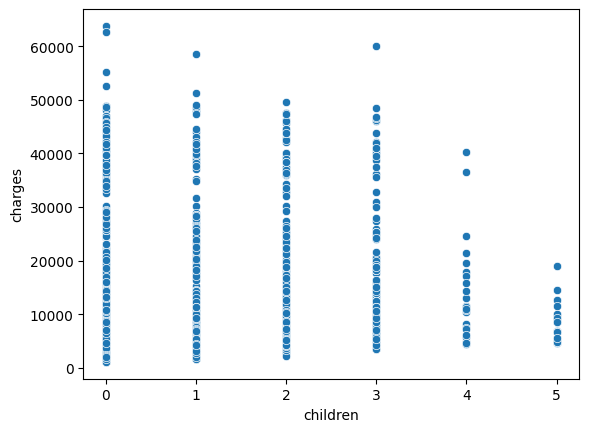

In [25]:
#scatter plot to understand the relationship
for i in ['age', 'bmi', 'children']:
    sns.scatterplot(data=df, x=i, y= 'charges')
    plt.show()

In [24]:
df.select_dtypes(include="number").columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [28]:
#correlation with heatmap to interpret the relation and multicolliniarity
s=df.select_dtypes(include="number").corr()

<Axes: >

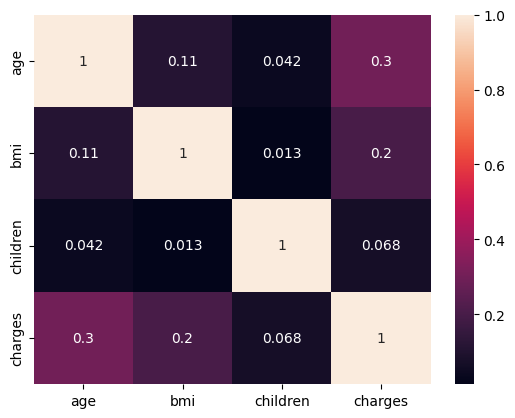

In [30]:
sns.heatmap(s,annot=True)

Step 6: outliers treatments


In [38]:
#Firstly, one has to decide whether to do outlier treatment or not
#handling outliers using wisker function
def wisker(col):
    q1,q3=np.percentile(col,[25,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

In [39]:
wisker(df['bmi'])

(np.float64(13.7), np.float64(47.290000000000006))

In [41]:
for i in ['bmi']:
    lw,uw=wisker(df[i])
    df[i]=np.where(df[i]<lw,lw,df[i])
    df[i]=np.where(df[i]>uw,uw,df[i])

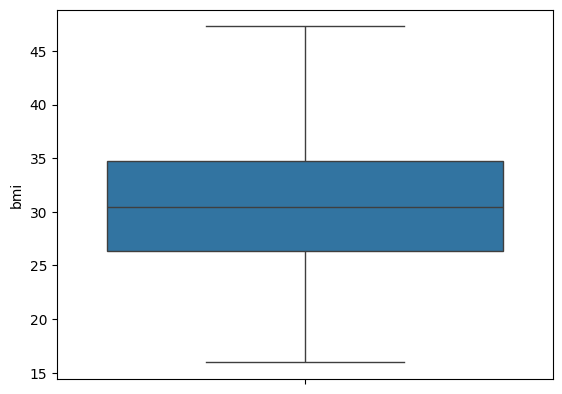

In [42]:
for i in['bmi']:
    sns.boxplot(df[i])
    plt.show()


Step 8: encoding of data

In [45]:
dummy=pd.get_dummies(data=df,columns=["region"],drop_first=True)

In [46]:
dummy

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,False,False,True
1,18,male,33.770,1,no,1725.55230,False,True,False
2,28,male,33.000,3,no,4449.46200,False,True,False
3,33,male,22.705,0,no,21984.47061,True,False,False
4,32,male,28.880,0,no,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830,True,False,False
1334,18,female,31.920,0,no,2205.98080,False,False,False
1335,18,female,36.850,0,no,1629.83350,False,True,False
1336,21,female,25.800,0,no,2007.94500,False,False,True
